**Normalization**

In [7]:
import pandas as pd

In [11]:
iris_df = pd.read_csv("Iris (2).csv",index_col= "Id")

In [12]:
iris_df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [13]:
iris_df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [14]:
from numpy import number
iris_df.corr(numeric_only = True)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


**Handling** **Normalization**

**min**-**max** **Normalization**

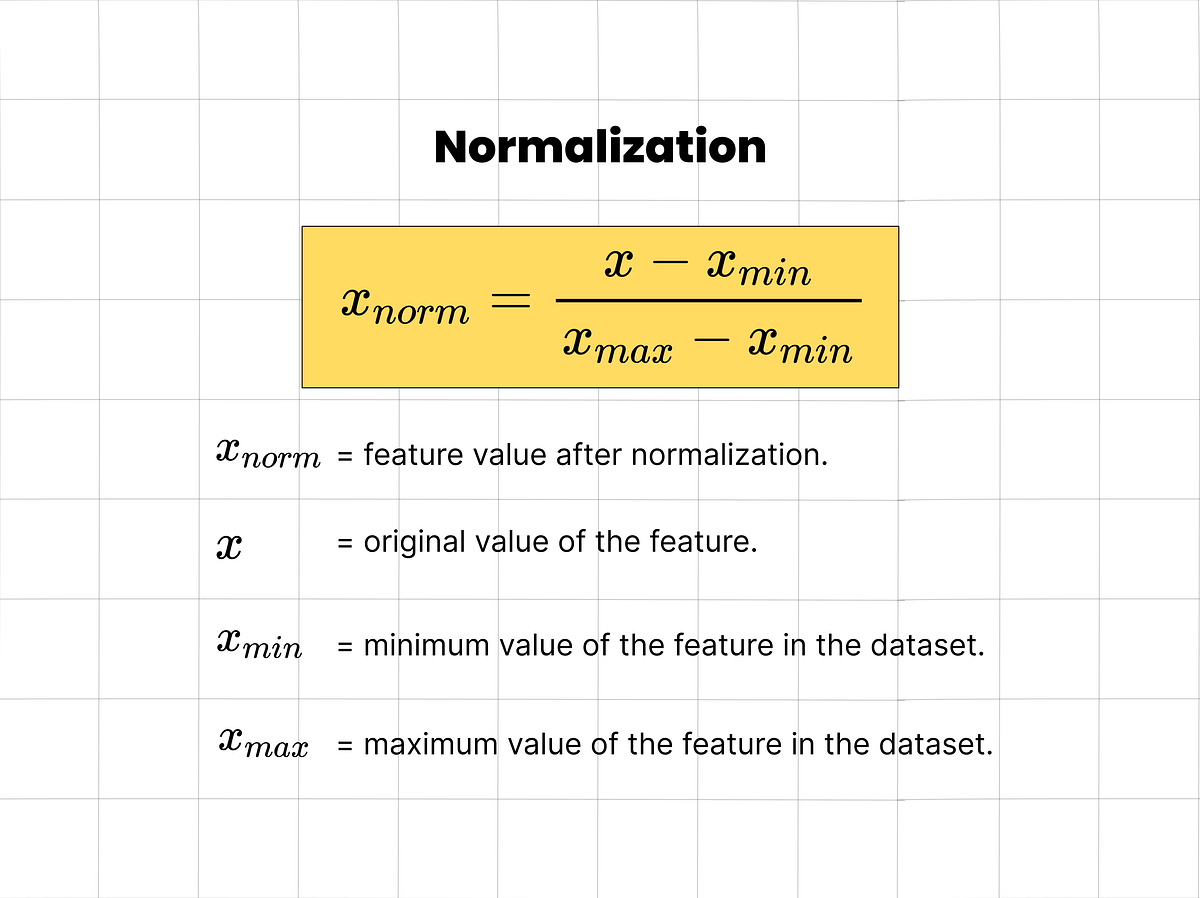

x_norm = (x-x_min) / (x_max - x_min)

In [15]:
min_length = iris_df.SepalLengthCm.min()
max_length = iris_df.SepalLengthCm.max()

In [16]:
iris_df.SepalLengthCm

,SepalLengthCm
Id,
1,5.1
2,4.9
3,4.7
4,4.6
5,5.0
...,...
146,6.7
147,6.3
148,6.5


In [18]:
normal_length = (iris_df.SepalLengthCm- min_length)/ (max_length-min_length)

In [19]:
normal_length

,SepalLengthCm
Id,
1,0.222222
2,0.166667
3,0.111111
4,0.083333
5,0.194444
...,...
146,0.666667
147,0.555556
148,0.611111


In [20]:
normal_length.describe()

,SepalLengthCm
count,150.000000
mean,0.428704
std,0.230018
min,0.000000
25%,0.222222
50%,0.416667
75%,0.583333
max,1.000000


<Axes: ylabel='Density'>

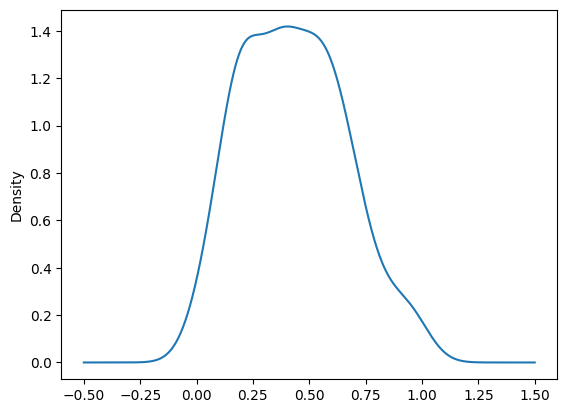

In [21]:
normal_length.plot.kde()

In [22]:
min_length = iris_df.PetalLengthCm.min()
max_length = iris_df.PetalLengthCm.max()

In [24]:
normal_length = (iris_df.PetalLengthCm- min_length)/ (max_length-min_length)

In [25]:
normal_length

,PetalLengthCm
Id,
1,0.067797
2,0.067797
3,0.050847
4,0.084746
5,0.067797
...,...
146,0.711864
147,0.677966
148,0.711864


In [26]:
normal_length.describe()

,PetalLengthCm
count,150.000000
mean,0.467571
std,0.299054
min,0.000000
25%,0.101695
50%,0.567797
75%,0.694915
max,1.000000


<Axes: ylabel='Density'>

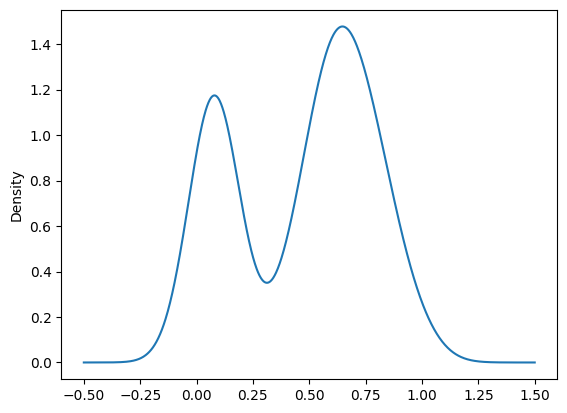

In [27]:
normal_length.plot.kde()

Drawbacks of minmax normalization

Highly sensitive to outliers (Biggest Oultier)

New data can change all values

not Robust for real world data

Advantage = proportional spacing, monotocity(relative order of value)

x_1 < x_2 original

x_1 < x_2 after scaling

To replace it we use Z-score normalization

In [30]:
df = pd.DataFrame({
    "marks": [20, 40, 60, 80, 1000]
})

In [31]:
from numpy import number
df.corr(numeric_only = True)

,marks
marks,1.0


In [32]:
min_length = df.marks.min()
max_length = df.marks.max()

In [33]:
normal_length = (df.marks- min_length)/ (max_length-min_length)

In [34]:
normal_length

,marks
0,0.000000
1,0.020408
2,0.040816
3,0.061224
4,1.000000


In [35]:
from sklearn.preprocessing import MinMaxScaler

In [37]:
minmax_scaler = MinMaxScaler(feature_range=(0,1))

In [39]:
norm_data = minmax_scaler.fit_transform(iris_df.drop("Species", axis=1))

In [40]:
norm_data

array([[0.22222222, 0.625     , 0.06779661, 0.04166667],
       [0.16666667, 0.41666667, 0.06779661, 0.04166667],
       [0.11111111, 0.5       , 0.05084746, 0.04166667],
       [0.08333333, 0.45833333, 0.08474576, 0.04166667],
       [0.19444444, 0.66666667, 0.06779661, 0.04166667],
       [0.30555556, 0.79166667, 0.11864407, 0.125     ],
       [0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.19444444, 0.58333333, 0.08474576, 0.04166667],
       [0.02777778, 0.375     , 0.06779661, 0.04166667],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.30555556, 0.70833333, 0.08474576, 0.04166667],
       [0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.        , 0.41666667, 0.01694915, 0.        ],
       [0.41666667, 0.83333333, 0.03389831, 0.04166667],
       [0.38888889, 1.        , 0.08474576, 0.125     ],
       [0.30555556, 0.79166667, 0.05084746, 0.125     ],
       [0.22222222, 0.625     ,

In [42]:
pd.DataFrame(norm_data, columns = ["SepalLengthCm", "SepalWigthCm", "PetalLengthCm", "PetalWigthCm"])

,SepalLengthCm,SepalWigthCm,PetalLengthCm,PetalWigthCm
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667
...,...,...,...,...
145,0.666667,0.416667,0.711864,0.916667
146,0.555556,0.208333,0.677966,0.750000
147,0.611111,0.416667,0.711864,0.791667
148,0.527778,0.583333,0.745763,0.916667


In [43]:
pd.DataFrame(norm_data, columns = ["SepalLengthCm", "SepalWigthCm", "PetalLengthCm", "PetalWigthCm"]).describe()

,SepalLengthCm,SepalWigthCm,PetalLengthCm,PetalWigthCm
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.439167,0.467571,0.457778
std,0.230018,0.180664,0.299054,0.317984
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


**Z**-**score** **Normalization**

In [ ]:
# Z-Score Normalization

In [45]:
Z_score = abs(iris_df.SepalLengthCm - iris_df.SepalLengthCm.mean())/iris_df.SepalLengthCm.std()

In [47]:
Z_score

,SepalLengthCm
Id,
1,0.897674
2,1.139200
3,1.380727
4,1.501490
5,1.018437
...,...
146,1.034539
147,0.551486
148,0.793012


In [48]:
round(Z_score.describe(),5)

,SepalLengthCm
count,150.00000
mean,0.83031
std,0.55313
min,0.05233
25%,0.41462
50%,0.79301
75%,1.13920
max,2.48370


<Axes: ylabel='Density'>

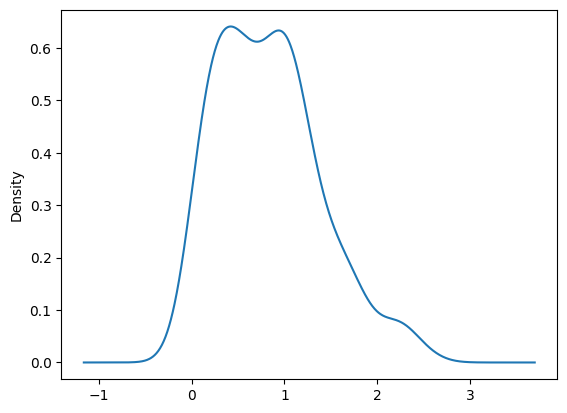

In [49]:
Z_score.plot.kde()

**Min-Max Scaler vs. StandardScaler: A Comparison**

Both **MinMaxScaler** and **StandardScaler** are commonly used for feature scaling in machine learning, but they behave differently and are suited for different situations.

**Comparison Table**
| Feature            | MinMaxScaler | StandardScaler |
|-------------------|-------------|---------------|
| **Range** | [0,1] (or custom range) | Mean = 0, Std = 1 |
| **Effect of Outliers** | Strong (compresses values) | Moderate (shifts distribution) |
| **Preserves Distribution?** | Yes (but not spacing) | No (reshapes to standard normal) |
| **Preserves Order?** | Yes | No (relative spacing changes) |
| **Best For?** | ML models needing bounded input (NN, KNN) | ML models assuming normal distribution (PCA, LR, SVM) |


In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
st_scaler = StandardScaler()

In [58]:
norm_data = st_scaler.fit_transform(iris_df.drop("Species", axis =1))

In [60]:
norm_data

array([[-9.00681170e-01,  1.03205722e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00, -1.24957601e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.38535265e+00,  3.37848329e-01, -1.39813811e+00,
        -1.31297673e+00],
       [-1.50652052e+00,  1.06445364e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.02184904e+00,  1.26346019e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-5.37177559e-01,  1.95766909e+00, -1.17067529e+00,
        -1.05003079e+00],
       [-1.50652052e+00,  8.00654259e-01, -1.34127240e+00,
        -1.18150376e+00],
       [-1.02184904e+00,  8.00654259e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.74885626e+00, -3.56360566e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00,  1.06445364e-01, -1.28440670e+00,
        -1.44444970e+00],
       [-5.37177559e-01,  1.49486315e+00, -1.28440670e+00,
        -1.31297673e+00],
       [-1.26418478e+00,  8.00654259e-01, -1.22754100e+00,
      

In [63]:
pd.DataFrame(norm_data, columns = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"])

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977
...,...,...,...,...
145,1.038005,-0.124958,0.819624,1.447956
146,0.553333,-1.281972,0.705893,0.922064
147,0.795669,-0.124958,0.819624,1.053537
148,0.432165,0.800654,0.933356,1.447956


In [64]:
pd.DataFrame(norm_data, columns = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]).describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-4.736952e-16,-6.631732e-16,3.315866e-16,-2.842171e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.438987e+00,-1.568735e+00,-1.444450e+00
25%,-9.006812e-01,-5.877635e-01,-1.227541e+00,-1.181504e+00
50%,-5.250608e-02,-1.249576e-01,3.362659e-01,1.332259e-01
75%,6.745011e-01,5.692513e-01,7.627586e-01,7.905908e-01
max,2.492019e+00,3.114684e+00,1.786341e+00,1.710902e+00


**Log transformation**

**Log transformation**

This method applies a logarithmic function to the data, to reduce the range of values and make the data more symmetric and normally distributed. The formula for log normalization is:

x_norm = log(x)

where x is the orginal value and x_norm is the normalizes value

Huge range difference lai gatauney

In [70]:
import numpy as np
data = np.arange(10, 5000, 50)

In [71]:
data

array([  10,   60,  110,  160,  210,  260,  310,  360,  410,  460,  510,
        560,  610,  660,  710,  760,  810,  860,  910,  960, 1010, 1060,
       1110, 1160, 1210, 1260, 1310, 1360, 1410, 1460, 1510, 1560, 1610,
       1660, 1710, 1760, 1810, 1860, 1910, 1960, 2010, 2060, 2110, 2160,
       2210, 2260, 2310, 2360, 2410, 2460, 2510, 2560, 2610, 2660, 2710,
       2760, 2810, 2860, 2910, 2960, 3010, 3060, 3110, 3160, 3210, 3260,
       3310, 3360, 3410, 3460, 3510, 3560, 3610, 3660, 3710, 3760, 3810,
       3860, 3910, 3960, 4010, 4060, 4110, 4160, 4210, 4260, 4310, 4360,
       4410, 4460, 4510, 4560, 4610, 4660, 4710, 4760, 4810, 4860, 4910,
       4960])

In [72]:
np.log(data).max()

np.float64(8.509161019718974)

In [73]:
transformed_data = np.log(iris_df.drop("Species", axis =1))
transformed_data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Id,,,,
1,1.629241,1.252763,0.336472,-1.609438
2,1.589235,1.098612,0.336472,-1.609438
3,1.547563,1.163151,0.262364,-1.609438
4,1.526056,1.131402,0.405465,-1.609438
5,1.609438,1.280934,0.336472,-1.609438


In [74]:
transformed_data.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,1.755393,1.106442,1.175498,-0.176944
std,0.141189,0.142341,0.589493,0.991394
min,1.458615,0.693147,0.000000,-2.302585
25%,1.629241,1.029619,0.470004,-1.203973
50%,1.757858,1.098612,1.470110,0.262364
75%,1.856298,1.193922,1.629241,0.587787
max,2.066863,1.481605,1.931521,0.916291


**Power Transformation**

4. **Power Transformation:**

   This method applies a power function to the data, to adjust the skewness and kurtosis of the distribution and make the data more symmetric and normally distributed. The formula for power normalization is:

```python
x_norm = sign(x) * abs(x) ** a
```

where `x` is the original value, `a` is the power parameter (typically between 0 and 1), `sign` is the sign function that returns the sign of x (+1 or -1), and `abs` is the absolute value function. The normalized value `x_norm` is obtained by raising the absolute value of `x` to the power of `a`, and then multiplying it by the sign of `x` to preserve the direction of the data.

In [76]:
power_factor = 0.7
normal_length = np.sign(iris_df.SepalLengthCm) * np.power(np.abs(iris_df.SepalLengthCm), power_factor)

In [77]:
normal_length

,SepalLengthCm
Id,
1,3.128233
2,3.041846
3,2.954395
4,2.910251
5,3.085169
...,...
146,3.786626
147,3.626923
148,3.707143


In [79]:
from scipy.stats import skewnorm
data = pd.DataFrame(skewnorm.rvs(10, size = 1000))

<Axes: ylabel='Density'>

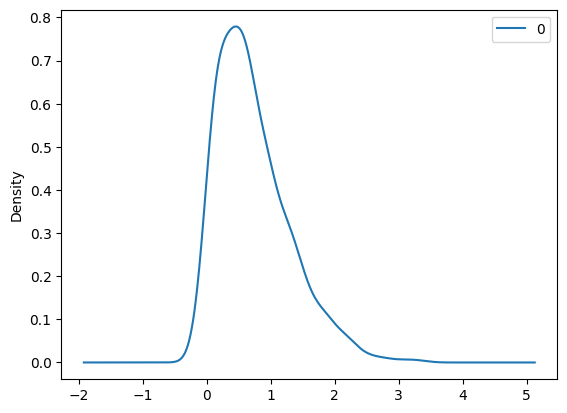

In [80]:
data.plot.kde()